**环境说明：** 请在运行下方 Spark 初始化代码前 **重启内核**（若曾报错），以便 `SPARK_HOME` 在首次加载 PySpark 前生效。诊断版本可在终端执行：`python3 -c "import pyspark; print(pyspark.__version__)"`。

In [1]:
import os
import sys
import importlib.util
import subprocess

# 在导入 pyspark 之前对齐 SPARK_HOME，避免 JVM 与 pip 中 pyspark 版本不一致
# （否则会报 org.apache.spark.sql.classic.SparkSession$ does not exist in the JVM）
_spec = importlib.util.find_spec("pyspark")
if _spec is None or not _spec.origin:
    raise RuntimeError("未找到 pyspark，请先安装：pip install pyspark")
os.environ["SPARK_HOME"] = os.path.dirname(_spec.origin)

try:
    _java_home = subprocess.check_output(
        "readlink -f $(which java) | sed 's|/bin/java||'",
        shell=True,
        text=True,
    ).strip()
    os.environ["JAVA_HOME"] = _java_home
except Exception:
    os.environ.setdefault("JAVA_HOME", "/usr/lib/jvm/java-17-openjdk")

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

# 若内核中已有旧的 SparkContext，先停止再创建会话
try:
    from pyspark import SparkContext

    _sc = SparkContext._active_spark_context
    if _sc is not None:
        _sc.stop()
except Exception:
    pass

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder.appName("MyProject")
    .config("spark.local.dir", "/root/spark_temp")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .config("spark.sql.debug.maxToStringFields", "2000")
    .getOrCreate()
)
spark.conf.set("spark.sql.debug.maxToStringFields", 2000)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/15 00:50:55 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/15 00:50:55 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in standalone/kubernetes and LOCAL_DIRS in YARN).


In [2]:
from pyspark.sql import functions as F

In [3]:
df = spark.read.csv("/root/my_proje1/train_data_extracted/elm_train.csv", header=False)
df.limit(5).show()

+---+--------------------+---+---+------------------+---+---+---+------+--------------------+--------------------+----+----+----------+------+------------+------+----+-----+----+----+----+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+----------+----+------+----+------------+
|_c0|                 _c1|_c2|_c3|               _c4|_c5|_c6|_c7|   _c8|                 _c9|                _c10|_c11|_c12|      _c13|  _c14|        _c15|  _c16|_c17| _c18|_c19|_c20|_c21|                _c22|                _c23|                _c24|                _c25|                _c26|                _c27|                _c28|                _c29|                _c30|                _c31|                _c32|                _c33|      _c34|_c35|  _c36|_c37|        _c38|
+---+--------------------+---+---+--

In [ ]:
print(df.count())

1990340


In [18]:
print(len(df.columns))

39


In [4]:
new_column_names = [ 
    "_c0",                                # _c0
    "user_id_masked",                     # 用户脱敏ID
    "user_gender",                        # 用户性别
    "user_visit_city_id",                 # 用户访问的城市ID
    "user_avg_price_hist",                # 用户历史平均单价
    "is_vip",                             # 用户是否开通VIP
    "user_click_rate_30d",                # 用户30天内的点击率
    "user_order_cnt_30d",                 # 用户三十天内的下单量
    "user_trade_amt_30d",                 # 用户30天内的交易金额
    "shop_id_masked",                     # 店铺脱敏ID
    "item_id_masked",                     # 商品脱敏ID
    "item_city_id",                       # 商品所处的城市ID
    "item_district_id",                   # 商品所处的区域ID
    "item_aoi_id",                        # 商品所处的aoi_ID
    "item_geohash6",                      # 商品所处的geohash6
    "item_geohash12",                     # 商品所处的geohash12
    "brand_id",                           # 品牌id
    "item_cat1_id",                       # 商品一级类目id
    "item_std_dish_cat_id",               # 商品标准菜类目id
    "item_sales_rank_7d",                 # 商品近7天在店内的畅销度排名
    "item_sales_rank_30d",                # 商品近30天在店内的畅销度排名
    "item_sales_rank_90d",                # 商品近90天在店内的畅销度排名
    "click_hist_shop_id_masked",                # 被点击的历史店铺脱敏id
    "click_hist_item_id_masked",                # 被点击的历史商品脱敏id
    "click_hist_item_cat1_id",                  # 被点击的历史商品一级类目id
    "click_hist_item_std_dish_id",              # 被点击的历史商品标准菜品id
    "click_hist_brand_id",                      # 被点击的历史商品品牌id
    "click_hist_item_price",                    # 被点击的历史商品的价格
    "click_hist_item_aoi_id",                   # 被点击的历史商品的aoi id
    "click_hist_item_geohash6",                 # 被点击的历史商品所处的geohash6
    "click_hist_time_diff_s",                   # 被点击的历史时间与当前时间的时间差(单位为s)
    "click_hist_click_hour",                    # 被点击的历史时间(h)
    "click_hist_click_time_slot",               # 被点击历史时间时间段
    "click_hist_click_day_of_week",             # 被点击历史时间星期几
    "request_timestamp",                  # 用户请求时间
    "current_hour",                       # 用户当前时间(hour)
    "current_time_slot",                  # 用户当前时间段
    "current_day_of_week",                # 用户当前星期几
    "user_geohash12"                      # 用户所处位置geohash12
]

In [5]:
print(f"当前列表长度: {len(new_column_names)}")
print(f"表格实际列数: {len(df.columns)}")

当前列表长度: 39
表格实际列数: 39


In [6]:
df = df.toDF(*new_column_names)
df.limit(5).show()

+---+--------------------+-----------+------------------+-------------------+------+-------------------+------------------+------------------+--------------------+--------------------+------------+----------------+-----------+-------------+--------------+--------+------------+--------------------+------------------+-------------------+-------------------+-------------------------+-------------------------+-----------------------+---------------------------+--------------------+---------------------+----------------------+------------------------+----------------------+---------------------+--------------------------+----------------------------+-----------------+------------+-----------------+-------------------+--------------+
|_c0|      user_id_masked|user_gender|user_visit_city_id|user_avg_price_hist|is_vip|user_click_rate_30d|user_order_cnt_30d|user_trade_amt_30d|      shop_id_masked|      item_id_masked|item_city_id|item_district_id|item_aoi_id|item_geohash6|item_geohash12|brand_i

##### 不执行----------------------------------------------------------------------------

In [19]:
df.limit(50).show()

+---+--------------------+-----------+------------------+-------------------+------+-------------------+------------------+------------------+--------------------+--------------------+------------+----------------+-----------+-------------+--------------+--------+------------+--------------------+------------------+-------------------+-------------------+-------------------------+-------------------------+-----------------------+---------------------------+--------------------+---------------------+----------------------+------------------------+----------------------+---------------------+--------------------------+----------------------------+-----------------+------------+-----------------+-------------------+--------------+
|_c0|      user_id_masked|user_gender|user_visit_city_id|user_avg_price_hist|is_vip|user_click_rate_30d|user_order_cnt_30d|user_trade_amt_30d|      shop_id_masked|      item_id_masked|item_city_id|item_district_id|item_aoi_id|item_geohash6|item_geohash12|brand_i

In [ ]:
## 这里修改时间戳会影响下面清洗，所以先不执行
df = df.withColumn("request_timestamp", F.from_unixtime(F.col("request_timestamp")).cast("timestamp"))

In [14]:
df.limit(5).show()

+---+--------------------+-----------+------------------+-------------------+------+-------------------+------------------+------------------+--------------------+--------------------+------------+----------------+-----------+-------------+--------------+--------+------------+--------------------+------------------+-------------------+-------------------+-------------------------+-------------------------+-----------------------+---------------------------+--------------------+---------------------+----------------------+------------------------+----------------------+---------------------+--------------------------+----------------------------+-----------------+------------+-----------------+-------------------+--------------+
|_c0|      user_id_masked|user_gender|user_visit_city_id|user_avg_price_hist|is_vip|user_click_rate_30d|user_order_cnt_30d|user_trade_amt_30d|      shop_id_masked|      item_id_masked|item_city_id|item_district_id|item_aoi_id|item_geohash6|item_geohash12|brand_i

In [17]:
df.explain("extended")

== Parsed Logical Plan ==
'Project [unresolvedstarwithcolumns(user_trade_amt_30d, cast('user_trade_amt_30d as float), None)]
+- Project [_c0#257, user_id_masked#258, user_gender#259, user_visit_city_id#260, cast(user_avg_price_hist#261 as float) AS user_avg_price_hist#453, is_vip#262, user_click_rate_30d#263, user_order_cnt_30d#264, user_trade_amt_30d#265, shop_id_masked#266, item_id_masked#267, item_city_id#268, item_district_id#269, item_aoi_id#270, item_geohash6#271, item_geohash12#272, brand_id#273, item_cat1_id#274, item_std_dish_cat_id#275, item_sales_rank_7d#276, item_sales_rank_30d#277, item_sales_rank_90d#278, click_hist_shop_id_masked#279, click_hist_item_id_masked#280, click_hist_item_cat1_id#281, click_hist_item_std_dish_id#282, click_hist_brand_id#283, click_hist_item_price#284, click_hist_item_aoi_id#285, click_hist_item_geohash6#286, click_hist_time_diff_s#287, click_hist_click_hour#288, click_hist_click_time_slot#289, click_hist_click_day_of_week#290, request_timestamp#

In [15]:
df.select("request_timestamp").printSchema()

root
 |-- request_timestamp: string (nullable = true)



In [16]:
df.select("request_timestamp").where(~F.col("request_timestamp").rlike("^[0-9]{10}$")).show(50, False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|request_timestamp                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [20]:
good = df.where(F.col("request_timestamp").rlike("^[0-9]{10}$")).count()
bad  = df.where(~F.col("request_timestamp").rlike("^[0-9]{10}$")).count()
print(good, bad, bad / (good + bad))

1965373 43 2.1878319907846483e-05


In [ ]:
## 查看时间跨度
stats = df.select(
    F.min("request_timestamp").alias("min_ts"),
    F.max("request_timestamp").alias("max_ts"),
    F.sum(F.col("request_timestamp").isNull().cast("int")).alias("null_ts"),
    F.count("*").alias("row_count")
).collect()[0] # collect() 将结果拉回到驱动端

# 2. 提取结果到 Python 变量
min_ts = stats["min_ts"]
max_ts = stats["max_ts"]
null_ts = stats["null_ts"]
row_count = stats["row_count"]

# 3. 打印
print("rows:", row_count)
print("null_ts:", null_ts)
print("min_ts:", min_ts)
print("max_ts:", max_ts)

26/04/14 20:02:59 ERROR Executor: Exception in task 5.0 in stage 17.0 (TID 663)]
org.apache.spark.SparkNumberFormatException: [CAST_INVALID_INPUT] The value '3;3;3;3;2;2;2;2;2;1;1;6;6;6;6;6;6;0;0;6;6;6;6;3;3;3;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;5;5;5;5;5;5;5;5' of the type "STRING" cannot be cast to "BIGINT" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018
== DataFrame ==
"from_unixtime" was called from
java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)

	at org.apache.spark.sql.errors.QueryExecutionErrors$.invalidInputInCastToNumberError(QueryExecutionErrors.scala:147)
	at org.apache.spark.sql.catalyst.util.UTF8StringUtils$.withException(UTF8StringUtils.scala:51)
	at org.apache.spark.sql.catalyst.util.UTF8StringUtils$.toLongExact(UTF8StringUtils.scala:31)
	at org.apache.spark.sql.catalyst.util.UTF8StringUtils.toLongExact(UTF8StringUtils.s

NumberFormatException: [CAST_INVALID_INPUT] The value '3;3;3;3;2;2;2;2;2;1;1;6;6;6;6;6;6;0;0;6;6;6;6;3;3;3;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;5;5;5;5;5;5;5;5' of the type "STRING" cannot be cast to "BIGINT" because it is malformed. Correct the value as per the syntax, or change its target type. Use `try_cast` to tolerate malformed input and return NULL instead. SQLSTATE: 22018
== DataFrame ==
"from_unixtime" was called from
java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)


##### 不执行-----------------------------------------------------------------------

In [7]:

df = df.where(F.col("request_timestamp").rlike("^[0-9]{10}$"))

In [8]:
import pandas as pd
from pyspark.sql import functions as F
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [9]:
## 删除重复值   
df=df.drop_duplicates()
## 这里做了改动，不做精确度转化
df = df.withColumn("user_avg_price_hist", F.col("user_avg_price_hist").cast("float"))
df = df.withColumn("user_trade_amt_30d", F.col("user_trade_amt_30d").cast("float"))
## 这里做了改动,C0代表正负样本，click_hist_time_diff_s代表活跃度，不作删除
new_head=df.limit(10).toPandas()

In [10]:
new_head.head(10)

,_c0,user_id_masked,user_gender,user_visit_city_id,user_avg_price_hist,is_vip,user_click_rate_30d,user_order_cnt_30d,user_trade_amt_30d,shop_id_masked,item_id_masked,item_city_id,item_district_id,item_aoi_id,item_geohash6,item_geohash12,brand_id,item_cat1_id,item_std_dish_cat_id,item_sales_rank_7d,item_sales_rank_30d,item_sales_rank_90d,click_hist_shop_id_masked,click_hist_item_id_masked,click_hist_item_cat1_id,click_hist_item_std_dish_id,click_hist_brand_id,click_hist_item_price,click_hist_item_aoi_id,click_hist_item_geohash6,click_hist_time_diff_s,click_hist_click_hour,click_hist_click_time_slot,click_hist_click_day_of_week,request_timestamp,current_hour,current_time_slot,current_day_of_week,user_geohash12
0,0,ab6e41595d947712478eab55d064deab2bddf64a4d5507f589c7dcb38b1b73fa,1,4,46.839230,1,49,13,608.909973,94c5f76b1c01990c4c0698b6ff8924dd67f9b16acaff8960a40535dbaba1cb2f,ba8cb6a3dc68fa88590e11034df240777f095803910ae2d9b37ea160921c4ef5,4,5624,B0FFG9JBX6,ws0s1s,ws0s1sv6g1jw,0,1066,0,1,1,1,1ea359d92ad9923756d7697d014110c9c880d0cbb153bb00c9c85e4aab39e694;fcae24ccef1812473a64e8cffa726befb414309216e87770308d751e8f740ae4;fcae24ccef1812473a64e8cffa726befb414309216e87770308d751e8f740ae4;fcae24ccef1812473a64e8cffa726befb414309216e87770308d751e8f740ae4;fcae24ccef1812473a64e8cffa726befb414309216e87770308d751e8f740ae4;fcae24ccef1812473a64e8cffa726befb414309216e87770308d751e8f740ae4;1ea359d92ad9923756d7697d014110c9c880d0cbb153bb00c9c85e4aab39e694;a7f9831bf015a7d4ce1b2716c3164a364f11bbe6330d6fba858135aecf446ca1;a7f9831bf015a7d4ce1b2716c3164a364f11bbe6330d6fba858135aecf446ca1;171276c642a46fed5ec0b69be1d851f23a897307339e1034eba79d70eec8df12;171276c642a46fed5ec0b69be1d851f23a897307339e1034eba79d70eec8df12;e235bf28a506e6fa5c9456c2ab2670bdb06fd1d138c118256603b9188bbcadd7;a4b6eb212c30f85d966ce726582bc766a1e9666ac39ab5a25ac92cb1a060107c;eaf29174f8469bfd0c17bf2521835a8708ca8b8e4cacb43c55b2baa9e34be421;eaf29174f8469bfd0c17bf2521835a8708ca8b8e4cacb43c55b2baa9e34be421;8c2183386842d7fa59fc8963429c3fe75e46424437888fda9c5606d01e72dbbe;8c2183386842d7fa59fc8963429c3fe75e46424437888fda9c5606d01e72dbbe;9f294aae18dbfd80a8e9f669a91887264f53d14686ce1ece45239300453ac08f;9f294aae18dbfd80a8e9f669a91887264f53d14686ce1ece45239300453ac08f;9f294aae18dbfd80a8e9f669a91887264f53d14686ce1ece45239300453ac08f;9f294aae18dbfd80a8e9f669a91887264f53d14686ce1ece45239300453ac08f;8c2183386842d7fa59fc8963429c3fe75e46424437888fda9c5606d01e72dbbe;8c2183386842d7fa59fc8963429c3fe75e46424437888fda9c5606d01e72dbbe;8c2183386842d7fa59fc8963429c3fe75e46424437888fda9c5606d01e72dbbe;8c2183386842d7fa59fc8963429c3fe75e46424437888fda9c5606d01e72dbbe;1ea359d92ad9923756d7697d014110c9c880d0cbb153bb00c9c85e4aab39e694;314825bf3b0acb6b851d2320bbca66167fe56ca237014854ba4353ab9fcc4084;314825bf3b0acb6b851d2320bbca66167fe56ca237014854ba4353ab9fcc4084;314825bf3b0acb6b851d2320bbca66167fe56ca237014854ba4353ab9fcc4084;314825bf3b0acb6b851d2320bbca66167fe56ca237014854ba4353ab9fcc4084;314825bf3b0acb6b851d2320bbca66167fe56ca237014854ba4353ab9fcc4084;c3cbce1ecd6bb84c942ae82cca203cfa8c6652f9a5e1594c72b092f4d0c1e233;1ea359d92ad9923756d7697d014110c9c880d0cbb153bb00c9c85e4aab39e694;2fb1ce63111d6b7fd62ec41b24a71750c7086a99912b70415c60561c4180aed4;2fb1ce63111d6b7fd62ec41b24a71750c7086a99912b70415c60561c4180aed4;2841ca79794ccb4d4ca8da1096e30e49bc380ace3f1d22e13bbbf3fca9be338b;2841ca79794ccb4d4ca8da1096e30e49bc380ace3f1d22e13bbbf3fca9be338b;c3cbce1ecd6bb84c942ae82cca203cfa8c6652f9a5e1594c72b092f4d0c1e233;c3cbce1ecd6bb84c942ae82cca203cfa8c6652f9a5e1594c72b092f4d0c1e233;c3cbce1ecd6bb84c942ae82cca203cfa8c6652f9a5e1594c72b092f4d0c1e233;42a54ef3089876b72257575b2671a83f78619ee46e248cdf58c9a3968876d9cb;4a04c2cff6273ed728763efd48557253be519400e2537a9fc1a894883ff495bf;4a04c2cff6273ed728763efd48557253be519400e2537a9fc1a894883ff495bf;8627060092b851847746f8ec11c9b1844b6f76bed5bfd23758726caac4f7fee3;8627060092b851847746f8ec11c9b1844b6f76bed5bfd23758726caac4f7fee3;fcae24ccef1812473a64e8cffa726befb414309216e87770308d751e8f740ae4;fcae24c

In [11]:
## 统计用户性别不用执行
from pyspark.sql import functions as F
vip_col = "user_gender"

df.groupBy(vip_col).count().orderBy(vip_col).show()

+-----------+-------+
|user_gender|  count|
+-----------+-------+
|       NULL|  94931|
|        -99| 170732|
|          1| 691455|
|          2|1008255|
+-----------+-------+



In [12]:
## 查看-99值，不用执行
from pyspark.sql import functions as F
exclude_cols = [    
    'click_hist_shop_id_masked',   
    'click_hist_item_id_masked',   
    'click_hist_time_diff_s',     
    'click_hist_item_cat1_id',       # 被点击的历史商品一级类目id
    'click_hist_item_std_dish_id',   # 被点击的历史商品标准菜品id
    'click_hist_brand_id',           # 被点击的历史商品品牌id
    'click_hist_item_price',         # 被点击的历史商品的价格
    'click_hist_item_aoi_id',        # 被点击的历史商品的aoi id
    'click_hist_item_geohash6',      # 被点击的历史商品所处的geohash6
    'click_hist_click_hour', 
    'click_hist_click_time_slot',     # 被点击的历史时间段（早餐晚餐中餐）
    'click_hist_click_day_of_week'   # 被点击历史时间星期几
]

# 2. 获取剩下的需要统计的列
cols_to_check = [c for c in df.columns if c not in exclude_cols]

# 3. 构造统计指令
stats = []
for c in cols_to_check:
    stats.append(F.count(F.when(F.col(c).cast("string") == "-99", c)).alias(f"{c}_99"))

print(f"正在统计 {len(cols_to_check)} 列的异常值（-99）...")
missing_df = df.select(stats)
missing_df2=missing_df.toPandas().T
missing_df2
##统计null和-1值

正在统计 27 列的异常值（-99）...


,0
_c0_99,0
user_id_masked_99,0
user_gender_99,170732
user_visit_city_id_99,0
user_avg_price_hist_99,0
is_vip_99,0
user_click_rate_30d_99,0
user_order_cnt_30d_99,0
user_trade_amt_30d_99,0
shop_id_masked_99,0


In [13]:
##统计null和-1值
exclude_cols = [   
    '_c0',
    'click_hist_shop_id_masked',   
    'click_hist_item_id_masked',   
    'click_hist_time_diff_s',         
    'click_hist_item_cat1_id',       # 被点击的历史商品一级类目id
    'click_hist_item_std_dish_id',   # 被点击的历史商品标准菜品id
    'click_hist_brand_id',           # 被点击的历史商品品牌id
    'click_hist_item_price',         # 被点击的历史商品的价格
    'click_hist_item_aoi_id',        # 被点击的历史商品的aoi id
    'click_hist_item_geohash6',      # 被点击的历史商品所处的geohash6
    'click_hist_click_hour', 
    'click_hist_click_time_slot',     # 被点击的历史时间段（早餐晚餐中餐）
    'click_hist_click_day_of_week'   # 被点击历史时间星期几
]

# 2. 获取剩下的需要统计的列
cols_to_check = [c for c in df.columns if c not in exclude_cols]

# 3. 构造统计指令
stats = []
for c in cols_to_check:
    # 统计 Null 值
    stats.append(F.count(F.when(F.col(c).isNull(), c)).alias(f"{c}_Null"))
    # 统计 -1 (转为字符串比较以防报错)
    stats.append(F.count(F.when(F.col(c).cast("string") == "-1", c)).alias(f"{c}_-1"))
    #这里去掉了0
    
# 4. 执行统计并逐列打印（避免 show(vertical=True) 因 maxToStringFields 省略 ...）
print(f"正在统计 {len(cols_to_check)} 列的异常值（Null,-1）...")
missing_df = df.select(stats)
_row = missing_df.collect()[0]
_w = max(len(c) for c in missing_df.columns)
for _c in missing_df.columns:
    print(f"{_c:{_w}s} | {_row[_c]}")

正在统计 26 列的异常值（Null,-1）...


user_id_masked_Null       | 0
user_id_masked_-1         | 0
user_gender_Null          | 94931
user_gender_-1            | 0
user_visit_city_id_Null   | 153557
user_visit_city_id_-1     | 0
user_avg_price_hist_Null  | 94931
user_avg_price_hist_-1    | 0
is_vip_Null               | 94931
is_vip_-1                 | 0
user_click_rate_30d_Null  | 94931
user_click_rate_30d_-1    | 0
user_order_cnt_30d_Null   | 94931
user_order_cnt_30d_-1     | 0
user_trade_amt_30d_Null   | 94931
user_trade_amt_30d_-1     | 0
shop_id_masked_Null       | 0
shop_id_masked_-1         | 0
item_id_masked_Null       | 0
item_id_masked_-1         | 0
item_city_id_Null         | 0
item_city_id_-1           | 26619
item_district_id_Null     | 0
item_district_id_-1       | 36154
item_aoi_id_Null          | 0
item_aoi_id_-1            | 478384
item_geohash6_Null        | 0
item_geohash6_-1          | 478384
item_geohash12_Null       | 0
item_geohash12_-1         | 478384
brand_id_Null             | 665
brand_id_-1     

In [ ]:
## 仅用于统计0值，可不执行
stats2 = []
for c in cols_to_check:
    # 统计 0 值
    stats2.append(F.count(F.when(F.col(c).cast("string") == "0", c)).alias(c))

missing_df2 = df.select(stats2)

pdf_result = missing_df2.toPandas().T

pdf_result.columns = ['Count_Zero']

pdf_result

,Count_Zero
_c0,399978
user_id_masked,0
user_gender,0
user_visit_city_id,0
user_avg_price_hist,0
is_vip,195595
user_click_rate_30d,15330
user_order_cnt_30d,37468
user_trade_amt_30d,0
shop_id_masked,0


In [47]:
col2_substitude=[
    'brand_id',
    'item_std_dish_cat_id',
    'item_cat1_id'
]
cols_to_check2_0 = [c for c in col2_substitude if c in df.columns]
update_exprs = [
    (
        F.when(
            (F.col(c).cast("string") == "-1") & F.lit(c in cols_to_check)
            | (F.col(c).cast("string") == "0") & F.lit(c in cols_to_check2_0)
            | (F.col(c)==-99) & F.lit(c in 'user_gender'),
            F.lit(None),
        ).otherwise(F.col(c)).alias(c)
    )
    for c in df.columns
]

# 2. 执行替换（产生新的 df）
df = df.select(*update_exprs)



## 这里所有缺失值都替换为null 

In [42]:
null_stats = [F.sum(F.col(c).isNull().cast("int")).alias(c) for c in cols_to_check]

# 2. 执行统计
print("正在计算全表各列的 Null 值总数...")
null_df = df.select(null_stats)

# 3. 显示结果：逐列打印，避免 Spark 纵向 show 中间出现 ...
_row = null_df.collect()[0].asDict()
_w = max(len(c) for c in null_df.columns)
for _c in null_df.columns:
    print(f"{_c:{_w}s} | {_row[_c]}")

正在计算全表各列的 Null 值总数...


_c0                  | 0
user_id_masked       | 0
user_gender          | 71209
user_visit_city_id   | 42692
user_avg_price_hist  | 27468
is_vip               | 27468
user_click_rate_30d  | 27468
user_order_cnt_30d   | 27468
user_trade_amt_30d   | 27468
shop_id_masked       | 0
item_id_masked       | 0
item_city_id         | 6587
item_district_id     | 8842
item_aoi_id          | 121034
item_geohash6        | 121034
item_geohash12       | 121034
brand_id             | 293183
item_cat1_id         | 194
item_std_dish_cat_id | 244899
item_sales_rank_7d   | 66573
item_sales_rank_30d  | 39656
item_sales_rank_90d  | 35297
request_timestamp    | 0
current_hour         | 0
current_time_slot    | 0
current_day_of_week  | 0
user_geohash12       | 6566


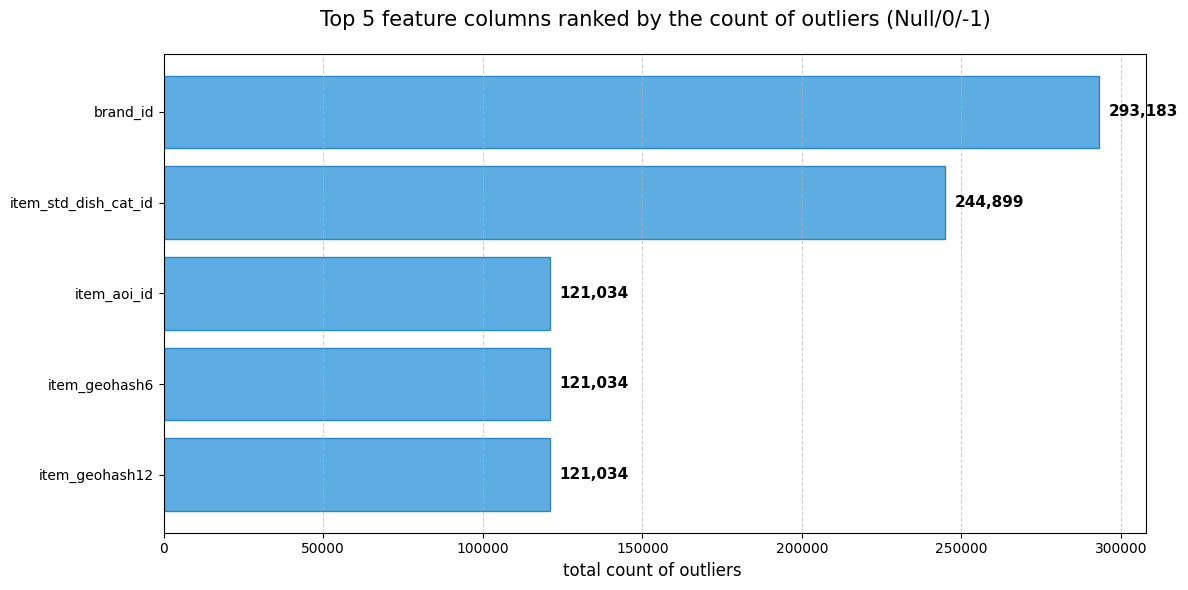

In [48]:
import matplotlib.pyplot as plt

# 1. 将 missing_df 的这一行数据转为 Python 字典
missing_row =null_df.collect()[0].asDict()

# 2. 排序并获取前五名 (按缺失数量从高到低)
# x[1] 代表数量，x[0] 代表列名
top_5_counts = sorted(missing_row.items(), key=lambda x: x[1], reverse=True)[:5]

# 3. 准备绘图数据 (为了让最大的排在上面，我们反转一下列表)
top_5_reversed = top_5_counts[::-1]
labels = [x[0] for x in top_5_reversed]
counts = [x[1] for x in top_5_reversed]

# 4. 绘图
plt.figure(figsize=(12, 6))
bars = plt.barh(labels, counts, color='#5DADE2', edgecolor='#2E86C1')

# 5. 美化图表
plt.title('Top 5 feature columns ranked by the count of outliers (Null/0/-1)', fontsize=15, pad=20)
plt.xlabel('total count of outliers ', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# 在条形末端添加具体的数值
for bar in bars:
    width = bar.get_width()
    plt.text(width + (max(counts) * 0.01), bar.get_y() + bar.get_height()/2, 
             f'{int(width):,}', ha='left', va='center', fontsize=11, fontweight='bold')


plt.tight_layout()
plt.show()

##### 三个特征缺失值一致，说明具有强关联性 
1. 强关联性：它们属于同一个“业务逻辑组”
这说明这三个字段是联动生成的。

逻辑推断：在原始数据录入时，这三个字段可能都依赖于同一个底层的“位置服务（LBS）”或“经纬度坐标”。

结论：如果某个样本（item）没有地理位置信息，那么这三个字段会同时缺失。它们共享同一个数据源头。

2. 字段冗余提示
geohash6 和 geohash12 本质上是经纬度的不同精度的编码（12位比6位更精确）。

信息重合：既然它们的缺失情况完全一样，说明它们提供的是同一维度的信息。在做 CTR 预估特征工程时，你可能不需要全部保留。

建议：通常保留一个精度适中的（如 geohash6 用于区域刻画）或者根据模型表现选一个即可，全放进去可能会增加模型的维度压力（维度灾难）。

3. 数据质量问题的定位
这个一致的数字（121,034）可以帮你反推数据流：

链路故障：可能是由于某些 item 本身就没有配置地理位置属性，或者是数据爬取/上报阶段，位置接口返回了空值。

业务含义：这部分缺失的样本是否集中在某些特定类型的“item”上？比如某些虚拟商品（没有物理位置）可能就会导致这三个地理特征集体缺失。

In [49]:
total_rows = df.count()
missing_data = null_df.collect()[0].asDict()
missing_percentages = {
    col_name: round((count / total_rows) * 100, 2) 
    for col_name, count in missing_data.items() 
    if count > 0
}
print(f"column with outliers and percentage")
sorted_missing = sorted(missing_percentages.items(), key=lambda x: x[1], reverse=True)
for col, percent in sorted_missing:
    print(f"{col:.<35} {percent}%")

column with outliers and percentage
brand_id........................... 59.4%
item_std_dish_cat_id............... 49.62%
item_aoi_id........................ 24.52%
item_geohash6...................... 24.52%
item_geohash12..................... 24.52%
user_gender........................ 14.43%
item_sales_rank_7d................. 13.49%
user_visit_city_id................. 8.65%
item_sales_rank_30d................ 8.03%
item_sales_rank_90d................ 7.15%
user_avg_price_hist................ 5.57%
is_vip............................. 5.57%
user_click_rate_30d................ 5.57%
user_order_cnt_30d................. 5.57%
user_trade_amt_30d................. 5.57%
item_district_id................... 1.79%
item_city_id....................... 1.33%
user_geohash12..................... 1.33%
item_cat1_id....................... 0.04%


## 缺失值 / 异常值（Null、0、-1）处理建议（对应上面缺失占比）

先把“缺失/异常”的取值统一成真正的 `null`，再按列类型填充或保留。

### 1）统一缺失值口径（建议先做）
- **把 `0` / `-1` 当缺失的列**：通常是计数/金额/排名/ID 等被用作占位符时。
- **不应该把 `0` 当缺失的列**：真实允许为 0 的指标（例如“近 30 天下单数=0”、“交易额=0”、“点击率=0”）。

示例（把 `-1` 统一转为 null；是否把 `0` 当缺失按列来定）：

```python
from pyspark.sql import functions as F

def to_null(df, cols, bad_values):
    """把 bad_values 里的值统一替换成 null"""
    for c in cols:
        cond = F.col(c).isNull()
        for v in bad_values:
            cond = cond | (F.col(c).cast('string') == str(v))
        df = df.withColumn(c, F.when(cond, F.lit(None)).otherwise(F.col(c)))
    return df

# 例：仅把 -1 当缺失（更安全）
cols_minus1 = [
    'brand_id','item_std_dish_cat_id','item_aoi_id','item_geohash6','item_geohash12',
    'item_sales_rank_7d','item_sales_rank_30d','item_sales_rank_90d',
    'user_gender','user_visit_city_id','item_cat1_id'
]
df1 = to_null(df, cols_minus1, bad_values=[-1])
```

### 2）按字段类型处理（推荐规则）
- **ID / 类别型（如 `brand_id`, `item_std_dish_cat_id`, `item_aoi_id`, `user_gender`, `user_visit_city_id`, `item_cat1_id`）**  
  - **做法**：用一个统一类别填充，例如 `'unknown'`（并转成 string 方便后续建模/编码）。

- **地理哈希（`item_geohash6`, `item_geohash12`, `user_geohash12`）**  
  - **做法**：缺失用 `'unknown'`；如果你后续会做 geohash 拆分/embedding，统一为字符串更稳。

- **排名类（`item_sales_rank_7d/30d/90d`）**  
  - **做法**：两种常见方案二选一：
    - **方案 A（推荐）**：缺失填一个很大的值（例如 `9999` 或 `max(rank)+1`），表示“没上榜/未知”。
    - **方案 B**：缺失填中位数/均值（不太推荐，会把“没上榜”当成普通排名）。

- **连续数值（如 `user_avg_price_hist`）**  
  - **做法**：用 **中位数** 填充（比均值抗异常值）。

- **计数/金额/比率（如 `user_order_cnt_30d`, `user_trade_amt_30d`, `user_click_rate_30d`）**  
  - **做法**：如果业务上“没有记录=0”成立，就填 **0**；如果 `-1` 是占位符，先转 null 再填 0。

### 3）一个可直接套用的批量填充模板

```python
from pyspark.sql import functions as F

# A. 类别列：缺失 -> 'unknown'
cat_cols = [
    'brand_id','item_std_dish_cat_id','item_aoi_id','item_geohash6','item_geohash12',
    'user_gender','user_visit_city_id','item_cat1_id'
]

df2 = df1
for c in cat_cols:
    df2 = df2.withColumn(
        c,
        F.when(F.col(c).isNull(), F.lit('unknown')).otherwise(F.col(c).cast('string'))
    )

# B. 排名列：缺失 -> 9999
rank_cols = ['item_sales_rank_7d','item_sales_rank_30d','item_sales_rank_90d']
df2 = df2.fillna({c: 9999 for c in rank_cols})

# C. 数值列：中位数/0 填充
median_price = df2.stat.approxQuantile('user_avg_price_hist', [0.5], 0.01)[0]
if median_price is None or median_price <= 0:
    median_price = 20.0

df2 = df2.fillna({
    'user_avg_price_hist': float(median_price),
    'user_order_cnt_30d': 0,
    'user_trade_amt_30d': 0,
    'user_click_rate_30d': 0.0,
})

df_filled = df2
```

### 4）建议你最后再验证一次
- 重新跑你上面统计缺失值占比的代码，确认这些高缺失列是否按预期变成 0%（或显著下降）。
- 如果后续要训练模型，建议再额外加一个 **缺失指示特征**（例如 `brand_id_is_missing`），有时能提升效果。

In [50]:
# 1. 自动找出缺失率在 0% 到 3% 之间的所有列
low_missing_cols = [col for col, per in missing_percentages.items() if 0 < per < 3]
print(f"检测到缺失率低于 3% 的列共有 {len(low_missing_cols)} 个：")
print(low_missing_cols)

检测到缺失率低于 3% 的列共有 4 个：
['item_city_id', 'item_district_id', 'item_cat1_id', 'user_geohash12']


In [51]:
df_cleaned_rows = df
for c in low_missing_cols:
    df_cleaned_rows = df_cleaned_rows.filter(F.col(c).isNotNull())

# 3. 查看处理后的总行数，看看损耗了多少
new_total = df_cleaned_rows.count()
print(f"\n原始总行数: {total_rows}")
print(f"处理后总行数: {new_total}")
print(f"共删除了 {total_rows - new_total} 行数据 (约占 {round((total_rows - new_total)/total_rows*100, 2)}%)")


原始总行数: 493550
处理后总行数: 484516
共删除了 9034 行数据 (约占 1.83%)


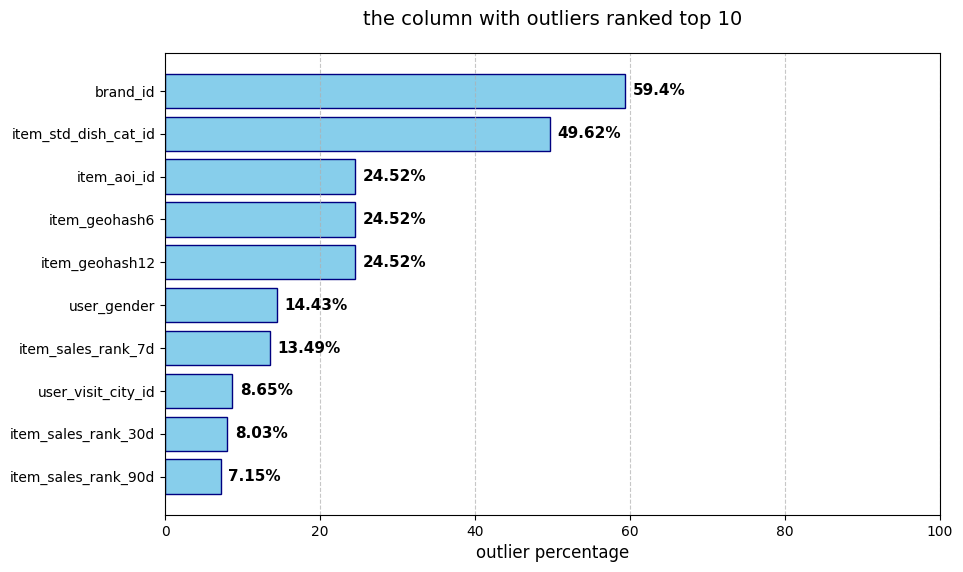

In [52]:
top_10 = sorted_missing[:10]
# 将数据反转，这样绘图时占比最高的会在最上方
top_10_reversed = top_10[::-1]

labels = [x[0] for x in top_10_reversed]
values = [x[1] for x in top_10_reversed]

# 2. 开始绘图
# 设置画布大小
plt.figure(figsize=(10, 6))

# 绘制横向条形图 (Horizontal Bar Chart)
bars = plt.barh(labels, values, color='skyblue', edgecolor='navy')

# 3. 美化图表
plt.xlabel('outlier percentage', fontsize=12)
plt.title('the column with outliers ranked top 10', fontsize=14, pad=20)
plt.xlim(0, 100)  # 设置X轴范围为 0-100%
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 4. 在条形图上添加具体的百分比文字
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'{width}%', ha='left', va='center', fontsize=11, fontweight='bold')

plt.show()

In [ ]:
## 仅查看vip类别 ，不用执行
vip_col = "is_vip"

df.groupBy(vip_col).count().orderBy(vip_col).show()

+------+------+
|is_vip| count|
+------+------+
|  NULL| 27468|
|     0|195595|
|     1|270487|
+------+------+



In [53]:
df2 = df_cleaned_rows
median_price = df2.stat.approxQuantile('user_avg_price_hist', [0.5], 0.01)[0]
if median_price is None or median_price <= 0:
    median_price = 20.0
print(median_price)

40.900001525878906


In [54]:
cat_cols = [
    'brand_id','item_std_dish_cat_id','item_aoi_id','item_geohash6','item_geohash12',
    'user_gender','user_visit_city_id'
]
# 处理类别列 unknown
for c in cat_cols:
    df2 = df2.withColumn(
        c,
        F.when(F.col(c).isNull(), F.lit('unknown')).otherwise(F.col(c).cast('string'))
    )

# B. 排名列：缺失 -> 9999
rank_cols = ['item_sales_rank_7d','item_sales_rank_30d','item_sales_rank_90d']
df2 = df2.fillna({c: 9999 for c in rank_cols})

# C. 数值列：中位数/0 填充
df2 = df2.fillna({
    'user_avg_price_hist': 40.9,
    'user_order_cnt_30d': 0,
    'user_trade_amt_30d': 0,
    'user_click_rate_30d': 0,
    'is_vip': 0
})

df_filled = df2

In [55]:
df_filled = df_filled.withColumn("user_avg_price_hist", F.col("user_avg_price_hist").cast("float"))

In [56]:
##转变时间戳
df_final = df_filled.withColumn("request_timestamp", F.from_unixtime(F.col("request_timestamp")).cast("timestamp"))

In [57]:
df_filled_show=df_final.limit(5).toPandas()
df_filled_show.head(5)

,_c0,user_id_masked,user_gender,user_visit_city_id,user_avg_price_hist,is_vip,user_click_rate_30d,user_order_cnt_30d,user_trade_amt_30d,shop_id_masked,item_id_masked,item_city_id,item_district_id,item_aoi_id,item_geohash6,item_geohash12,brand_id,item_cat1_id,item_std_dish_cat_id,item_sales_rank_7d,item_sales_rank_30d,item_sales_rank_90d,click_hist_shop_id_masked,click_hist_item_id_masked,click_hist_item_cat1_id,click_hist_item_std_dish_id,click_hist_brand_id,click_hist_item_price,click_hist_item_aoi_id,click_hist_item_geohash6,click_hist_time_diff_s,click_hist_click_hour,click_hist_click_time_slot,click_hist_click_day_of_week,request_timestamp,current_hour,current_time_slot,current_day_of_week,user_geohash12
0,0,601b640aa477c38bcdcfabc4108a6c3264123e2774cadf1266a0085076bca789,2,14,90.387779,1,139,45,4067.449951,a351d550ead292285c2b62b056ad68472fa3bcd4c0f0e1e7b9d4a8d623aefc21,4f29469f9ea86086d01eab3594650665c98f91d6fedf8a18dc858e450d5ad1dd,14,5746,B0FFG7LQ2U,wm6n3d,wm6n3dypbkqk,unknown,1066,22614,1,1,1,69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;69b2f6a7b7b88a57ee5864995590afab7eeaf5ffd7ded0f5772a05ef2dc0a3c7;2509622a17c9bb563de5683afb9f905f06da60fdb043dcf65ff6926d07668037;2509622a17c9bb563de5683afb9f905f06da60fdb043dcf65ff6926d07668037;02e00be0a5710683d42ffedb29b2cc9884120aa69833133d41e1306fc6035088;146e47dfe5fc5d70017e404e2f8f31c5fb603d73ee7cd4a26c056b9b506f4f46;311a0c5f6887ccea35b1812580fee63526a978328f5ee87aa327d634cbf241f5;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;6ebdabbcc846cbc83789a0ba09edd0386b87032f317f65e2393d08bb1e423337;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300bd7c14;ca26884e5177b47452b46cc32f4d7e1677560a41025351b5e286ea615d8ed196;ca26884e5177b47452b46cc32f4d7e1677560a41025351b5e286ea615d8ed196;ca26884e5177b47452b46cc32f4d7e1677560a41025351b5e286ea615d8ed196;ca26884e5177b47452b46cc32f4d7e1677560a41025351b5e286ea615d8ed196;06dd9d5f8c72f4d74d7331effb646820ddea20d389c690b983a080417c04e0f7;06dd9d5f8c72f4d74d7331effb646820ddea20d389c690b983a080417c04e0f7;06dd9d5f8c72f4d74d7331effb646820ddea20d389c690b983a080417c04e0f7;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;4fd1ad2a3a431a5d986659e3e56becb7d67a7a50b6352e5c2e9eb370b36158b4;d5f179dfc60d777b7894ed521e895faedbc99a140a499f1cb1a451a300

In [58]:
# 保存为 Parquet 文件夹
df_final.write.mode("overwrite").parquet("cleaned_data.parquet")
print("数据已成功保存为 Parquet 格式！")

数据已成功保存为 Parquet 格式！


In [ ]:
##通过Geohash可以大致比较用户和商家是否在同一区域  
##用户历史平均单价 交易金额 要改成整数
# 删除被点击的历史时间与当前时间的时间差
##AOI ID 通常是指 Area of Interest ID
## Geohash6 和 Geohash12 的核心区别在于：字符越长，代表的地理范围越精准，误差越小。
##去空值缺失值并统计
##数据透视表，建立关联表
## AI赋值
##删掉时间戳 时间戳处理
##

### 一阶段清洗结束

In [4]:
## 查看时间戳范围
df = spark.read.parquet("/root/my_proje1/tables/fact_request.parquet", header=False)
df.limit(5).show()

+--------------------+--------------------+--------------------+-------------------+------------+-----------------+-------------------+--------------+
|      user_id_masked|      shop_id_masked|      item_id_masked|  request_timestamp|current_hour|current_time_slot|current_day_of_week|user_geohash12|
+--------------------+--------------------+--------------------+-------------------+------------+-----------------+-------------------+--------------+
|1c229225ff34e6cf4...|3e319160f39f39da5...|5c83ab6c00342d7a9...|2022-04-02 12:09:56|          12|            lunch|                  5|  wsvz1ne7t1rn|
|b0d894f8237721dcf...|4888e5df6ea671ac8...|54352f0a68877ed8b...|2022-04-02 11:43:24|          11|            lunch|                  5|  wt9nvpn3ub6e|
|a9a5d214399634d6b...|4cddca78319581979...|2ecbacefca4ea1fb6...|2022-04-02 11:57:55|          11|            lunch|                  5|  wwmt68jfv73m|
|78a88020e29d63ca7...|c97901bf11230c6a1...|00fdee2074b828098...|2022-04-02 21:34:36|          

In [6]:
stats = df.select(
    F.min("request_timestamp").alias("min_ts"),
    F.max("request_timestamp").alias("max_ts"),
    F.sum(F.col("request_timestamp").isNull().cast("int")).alias("null_ts"),
    F.count("*").alias("row_count")
).collect()[0] # collect() 将结果拉回到驱动端

# 2. 提取结果到 Python 变量
min_ts = stats["min_ts"]
max_ts = stats["max_ts"]
null_ts = stats["null_ts"]
row_count = stats["row_count"]

# 3. 打印
print("rows:", row_count)
print("null_ts:", null_ts)
print("min_ts:", min_ts)
print("max_ts:", max_ts)

rows: 471416
null_ts: 0
min_ts: 2022-04-02 00:00:00
max_ts: 2022-04-02 23:59:56


In [2]:
df = spark.read.parquet("/root/my_proje1/cleaned_data.parquet", header=False)
df.limit(5).show()

+--------------------+-----------+------------------+-------------------+------+-------------------+------------------+------------------+--------------------+--------------------+------------+----------------+-----------+-------------+--------------+--------+------------+--------------------+------------------+-------------------+-------------------+-------------------------+-------------------------+-----------------------+---------------------------+--------------------+---------------------+----------------------+------------------------+---------------------+--------------------------+----------------------------+-------------------+------------+-----------------+-------------------+--------------+
|      user_id_masked|user_gender|user_visit_city_id|user_avg_price_hist|is_vip|user_click_rate_30d|user_order_cnt_30d|user_trade_amt_30d|      shop_id_masked|      item_id_masked|item_city_id|item_district_id|item_aoi_id|item_geohash6|item_geohash12|brand_id|item_cat1_id|item_std_dish_

In [5]:
hist_cols = [
    "click_hist_shop_id_masked",
    "click_hist_item_id_masked",
    "click_hist_item_cat1_id",
    "click_hist_item_std_dish_id",
    "click_hist_brand_id",
    "click_hist_item_price",
    "click_hist_item_aoi_id",
    "click_hist_item_geohash6",
    "click_hist_click_hour",
    "click_hist_click_time_slot",
    "click_hist_click_day_of_week",
]

def str_to_array(col_name: str):
    s = F.trim(F.col(col_name))
    # 空串 -> 空数组；否则按分号拆分
    return F.when(s == "", F.array()).otherwise(F.split(s, ";"))

for c in hist_cols:
    df = df.withColumn(c, str_to_array(c))

In [6]:
df.limit(5).show()

+--------------------+-----------+------------------+-------------------+------+-------------------+------------------+------------------+--------------------+--------------------+------------+----------------+-----------+-------------+--------------+--------+------------+--------------------+------------------+-------------------+-------------------+-------------------------+-------------------------+-----------------------+---------------------------+--------------------+---------------------+----------------------+------------------------+---------------------+--------------------------+----------------------------+-------------------+------------+-----------------+-------------------+--------------+
|      user_id_masked|user_gender|user_visit_city_id|user_avg_price_hist|is_vip|user_click_rate_30d|user_order_cnt_30d|user_trade_amt_30d|      shop_id_masked|      item_id_masked|item_city_id|item_district_id|item_aoi_id|item_geohash6|item_geohash12|brand_id|item_cat1_id|item_std_dish_

In [ ]:
df.write.mode("overwrite").parquet("cleaned_data.parquet")
print("数据已成功保存为 Parquet 格式！")

In [ ]:
# 用户表：记录用户的静态/长期属性
user_cols = [
    "user_id_masked", "user_gender", "user_visit_city_id", 
    "user_avg_price_hist", "is_vip", "user_click_rate_30d", 
    "user_order_cnt_30d", "user_trade_amt_30d"
]

# 商品与店铺表：记录商品的品牌、类目、排名和地理信息
item_cols = [
    "item_id_masked", "shop_id_masked", "item_city_id", 
    "item_district_id", "item_aoi_id", "item_geohash6", 
    "item_geohash12", "brand_id", "item_cat1_id", 
    "item_std_dish_cat_id", "item_sales_rank_7d", 
    "item_sales_rank_30d", "item_sales_rank_90d"
]

# 上下文与行为序列表：记录每次请求时的环境和历史点击流
behavior_cols = [
    "user_id_masked", "item_id_masked", "request_timestamp", 
    "current_hour", "current_time_slot", "current_day_of_week", 
    "user_geohash12", "click_hist_item_id_masked", "click_hist_item_cat1_id", 
    "click_hist_item_std_dish_id", "click_hist_brand_id", "click_hist_item_price", 
    "click_hist_item_aoi_id", "click_hist_item_geohash6", "click_hist_click_hour", 
    "click_hist_click_time_slot", "click_hist_click_day_of_week"
]

In [ ]:
# 用户表和商品表需要 distinct()，因为同一个用户/商品在原始 50 万行中会出现多次
df_user = df_final.select(user_cols).distinct()
df_item = df_final.select(item_cols).distinct()

# 行为表不需要去重，因为它代表了每一条真实的点击/请求记录
df_behavior = df_final.select(behavior_cols)


In [ ]:
df_user.write.mode("overwrite").option("header","true").csv("data_warehouse/user_profile2.csv")
# 导出商品表
df_item.write.mode("overwrite").option("header","true").csv("data_warehouse/item_profile2.csv")
# 导出交互行为表
df_behavior.write.mode("overwrite").option("header","true").csv("data_warehouse/user_behavior_context2.csv")

print("✅ 三张表已成功导出至 'data_warehouse' 文件夹中！")

# --- 4. 验证：查看拆分后的规模 ---
print(f"原始记录总数: {df_final.count()}")
print(f"独立用户总数: {df_user.count()}")
print(f"独立商品总数: {df_item.count()}")

✅ 三张表已成功导出至 'data_warehouse' 文件夹中！


原始记录总数: 500000


独立用户总数: 400779


独立商品总数: 311852


In [ ]:
df_cleaned = spark.read.parquet("/root/my_proje1/cleaned_data.parquet")
df_cleaned.limit(5).show()


+--------------------+-----------+------------------+-------------------+------+-------------------+------------------+------------------+--------------------+--------------------+------------+----------------+-----------+-------------+--------------+--------+------------+--------------------+------------------+-------------------+-------------------+-------------------------+-------------------------+-----------------------+---------------------------+--------------------+---------------------+----------------------+------------------------+---------------------+--------------------------+----------------------------+-------------------+------------+-----------------+-------------------+--------------+
|      user_id_masked|user_gender|user_visit_city_id|user_avg_price_hist|is_vip|user_click_rate_30d|user_order_cnt_30d|user_trade_amt_30d|      shop_id_masked|      item_id_masked|item_city_id|item_district_id|item_aoi_id|item_geohash6|item_geohash12|brand_id|item_cat1_id|item_std_dish_

In [ ]:
df_cleaned2 = df_cleaned.withColumn("request_timestamp", F.date_trunc("minute", F.col("request_timestamp")))

In [ ]:
df_cleaned2 = df_cleaned2.withColumn(
    "brand_id",
    F.when(F.col("brand_id").cast("string") == "unknown", F.lit(None))
     .otherwise(F.col("brand_id"))
).withColumn(
    "user_gender",
    F.when(F.trim(F.col("user_gender").cast("string")) == "-99", F.lit(None))
     .otherwise(F.col("user_gender"))
)


In [ ]:
df_cleaned2.limit(5).show()

+--------------------+-----------+------------------+-------------------+------+-------------------+------------------+------------------+--------------------+--------------------+------------+----------------+-----------+-------------+--------------+--------+------------+--------------------+------------------+-------------------+-------------------+-------------------------+-------------------------+-----------------------+---------------------------+--------------------+---------------------+----------------------+------------------------+---------------------+--------------------------+----------------------------+-------------------+------------+-----------------+-------------------+--------------+
|      user_id_masked|user_gender|user_visit_city_id|user_avg_price_hist|is_vip|user_click_rate_30d|user_order_cnt_30d|user_trade_amt_30d|      shop_id_masked|      item_id_masked|item_city_id|item_district_id|item_aoi_id|item_geohash6|item_geohash12|brand_id|item_cat1_id|item_std_dish_